<h3> SciPython/Practical_classes_6

<h3> Decision trees

In [2]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


iris = datasets.load_iris()
X = iris.data[:, [2,3]]
y = iris.target
np.unique(y)

array([0, 1, 2])

In [3]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=0)

In [4]:
from sklearn.tree import DecisionTreeClassifier

- Entropy criterion

In [5]:
tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
tree.fit(X_train, y_train);

In [6]:
tree.score(X_test, y_test)

0.9777777777777777

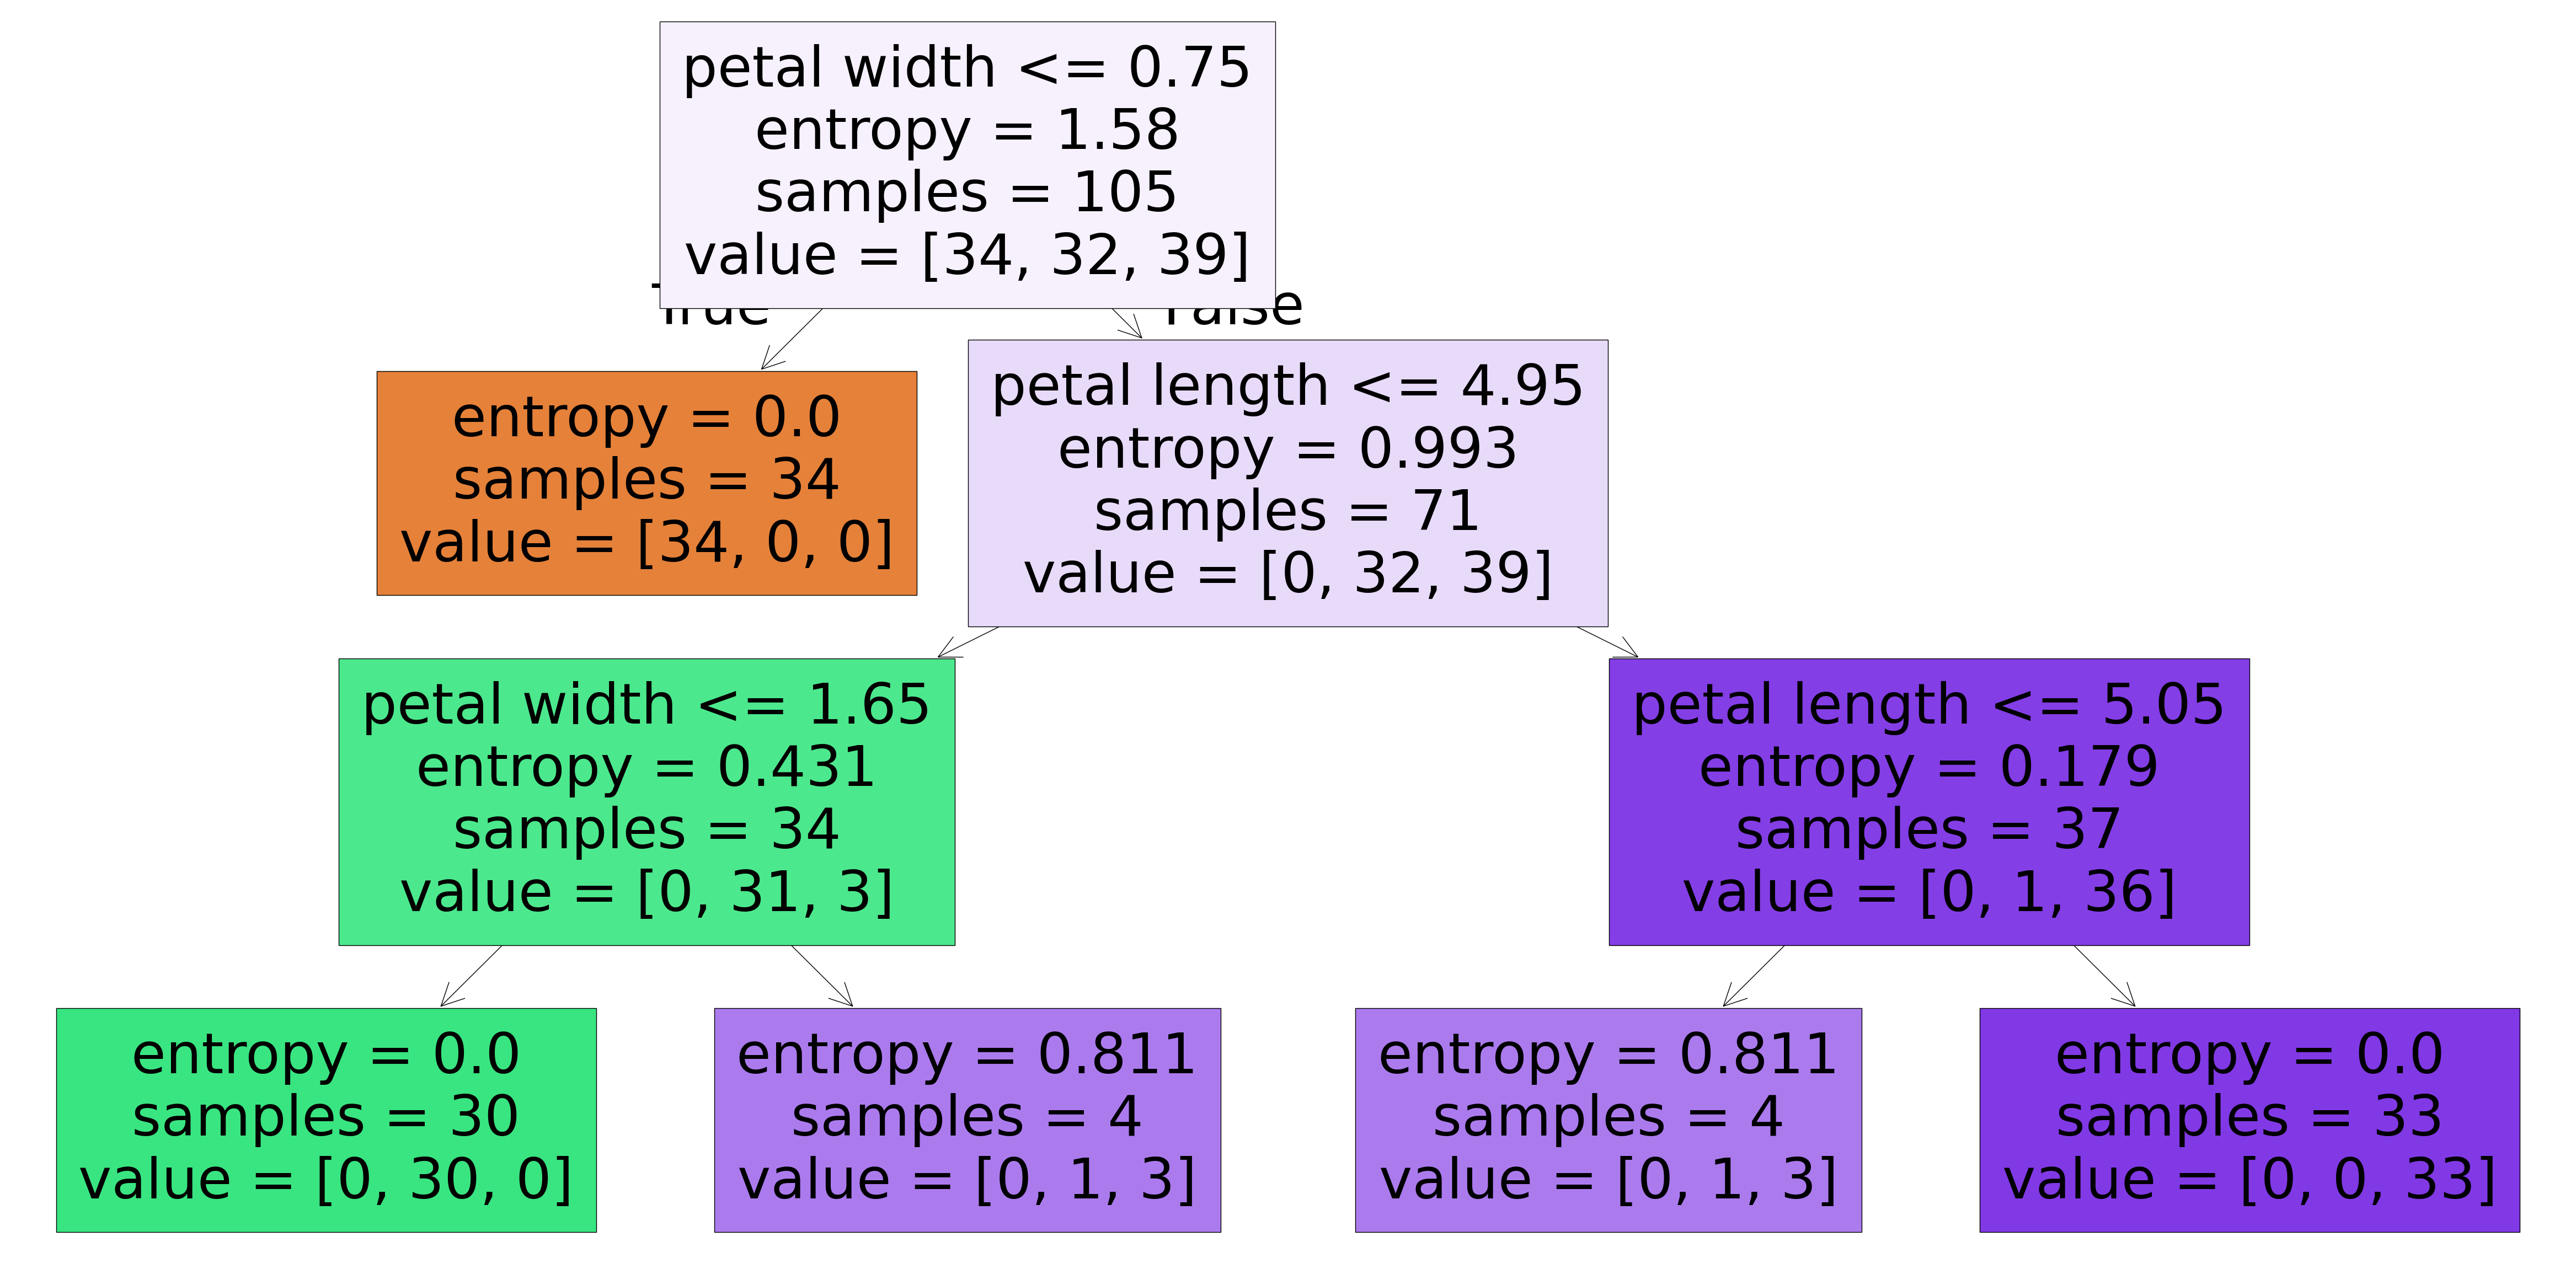

In [7]:
from sklearn.tree import plot_tree
plt.figure(figsize=(60,30))
plot_tree(tree, filled=True, feature_names=['petal length', 'petal width']);

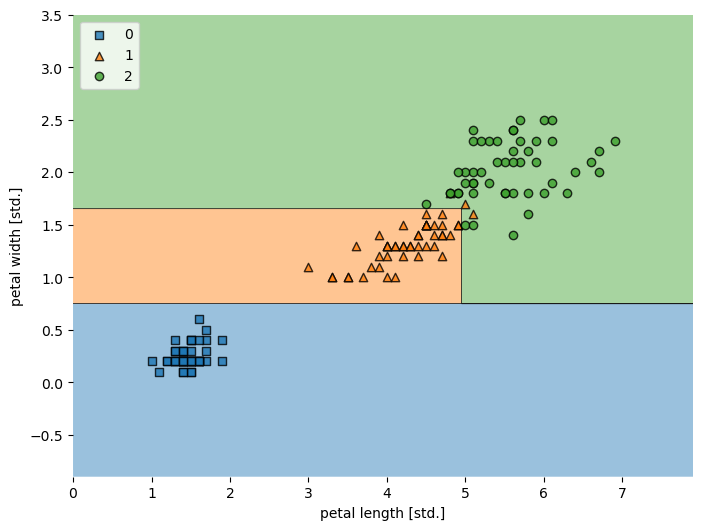

In [9]:
from mlxtend.plotting import plot_decision_regions

plt.figure(figsize=(8, 6))
plot_decision_regions( X=X, y=y, clf=tree)
plt.xlabel('petal length [std.]')
plt.ylabel('petal width [std.]')
plt.legend(loc='upper left')
plt.show()

In [10]:
print(tree.predict([[1.4, 0.2]]))
print()
print(tree.predict([[5.1, 1.8]]))

[0]

[2]


- Gini index criterion

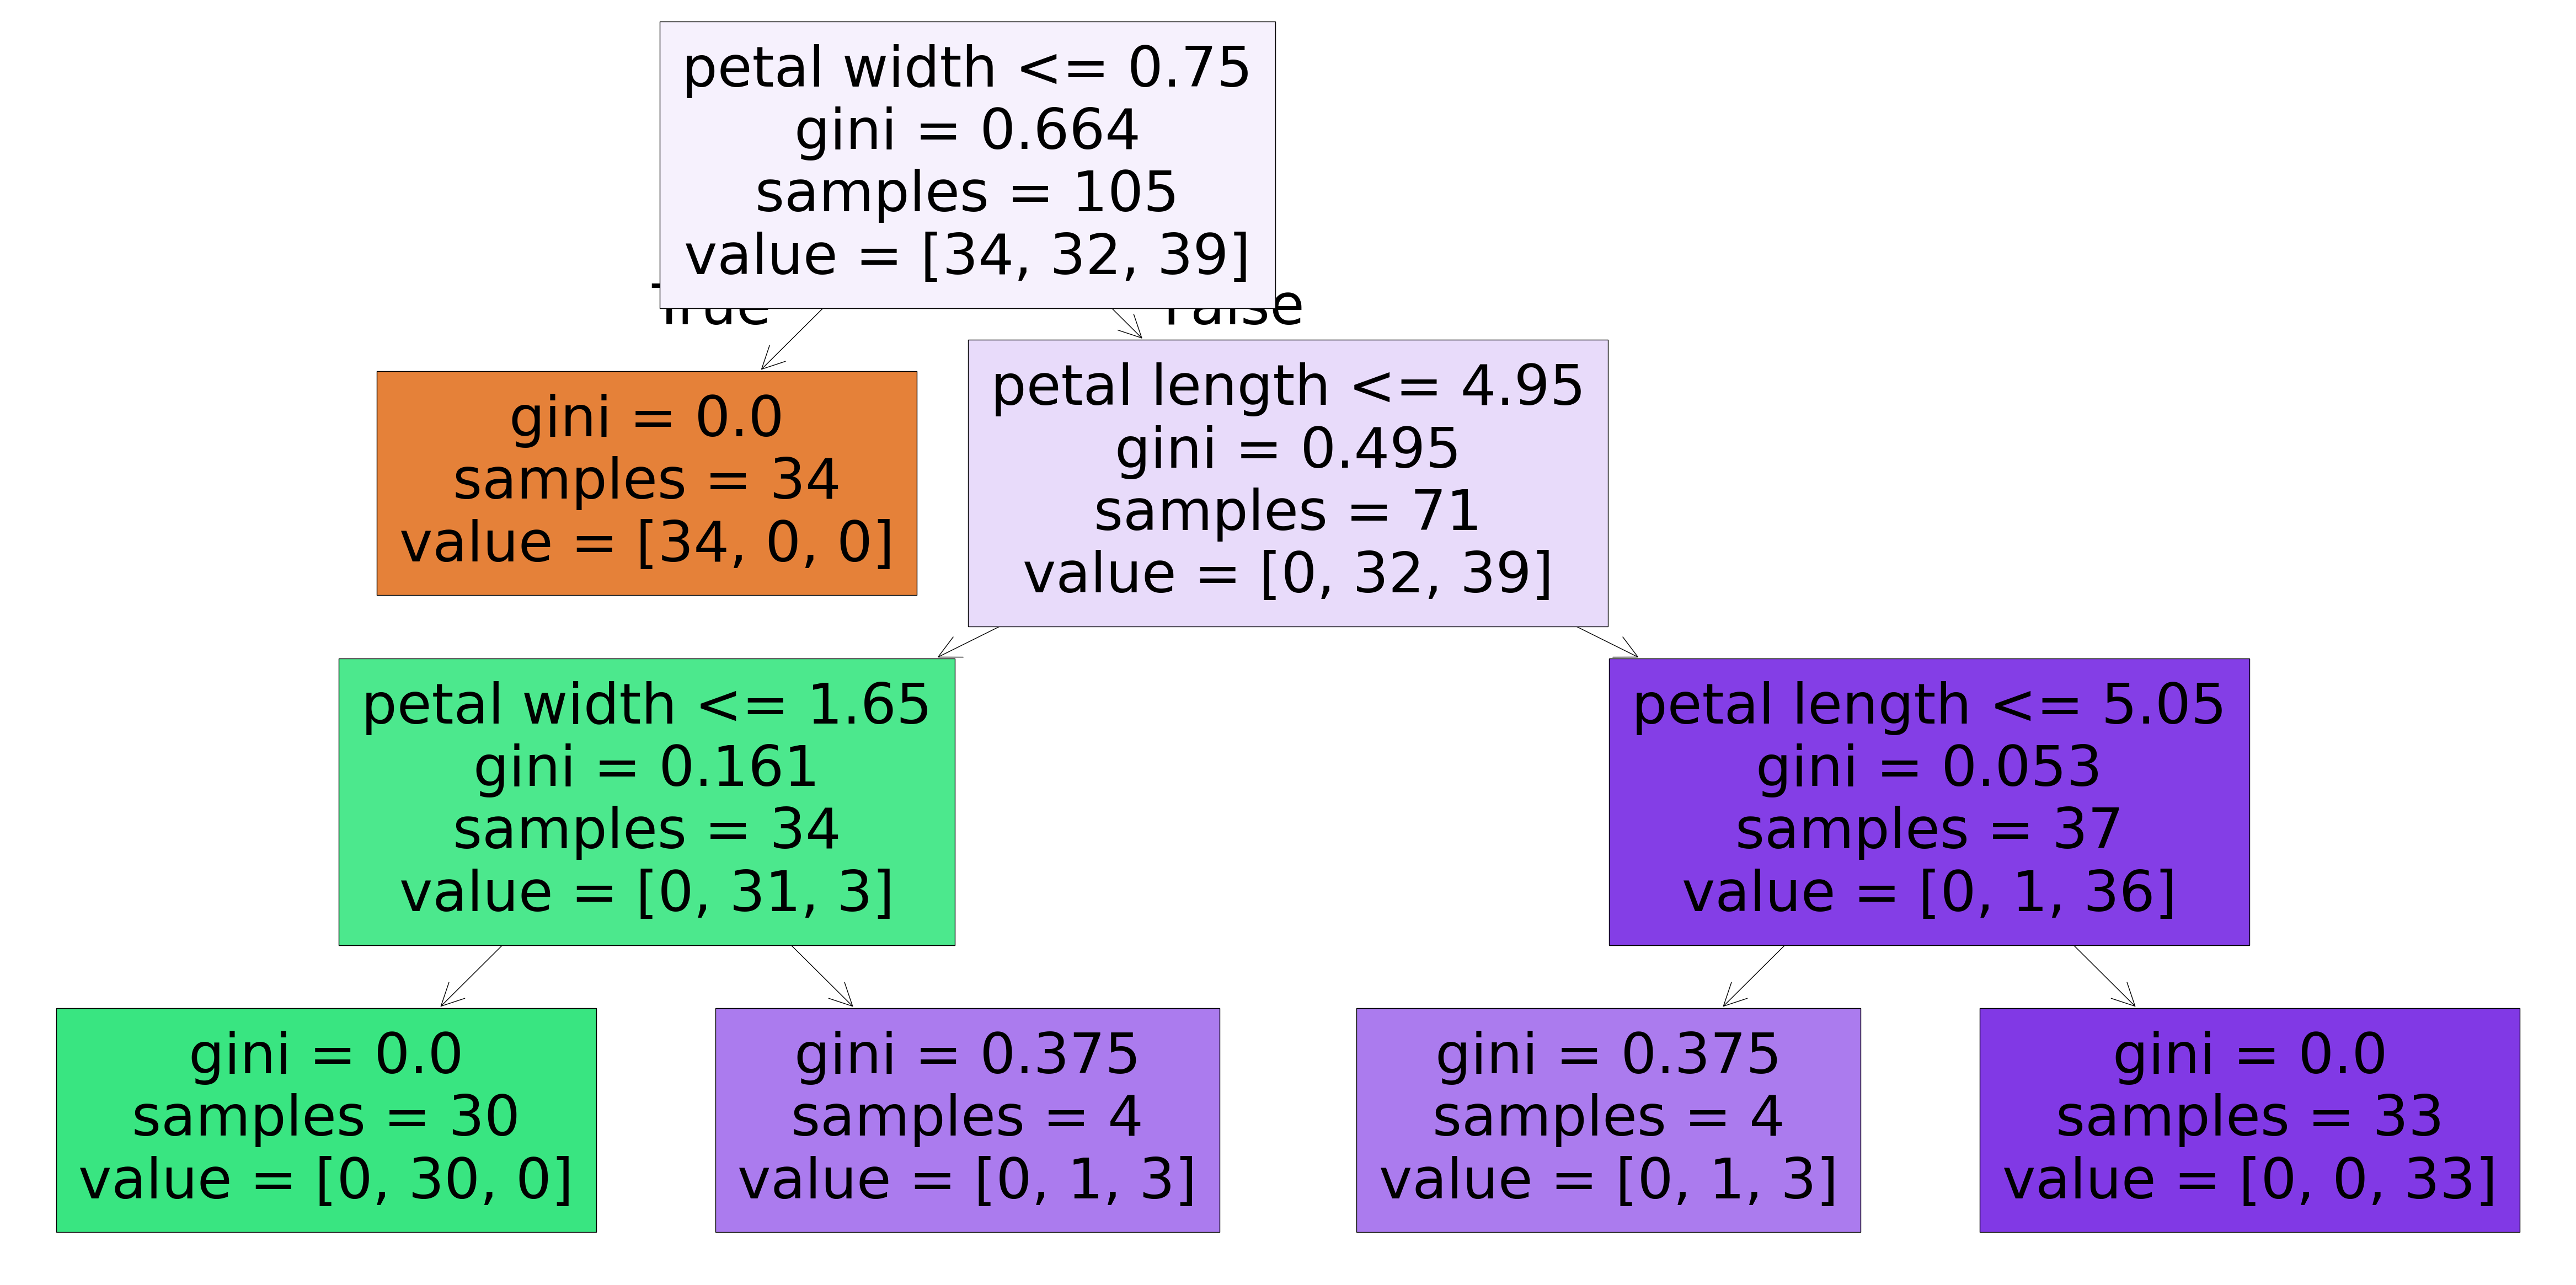

In [11]:
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
tree_gini.fit(X_train, y_train)

plt.figure(figsize=(60,30))
plot_tree(tree_gini, filled=True, feature_names=['petal length', 'petal width']);

* Decision trees learn fast! :)

In [12]:
import pandas as pd
df = pd.read_csv("C:/Users/Adrian/Desktop/Dydaktyka/SciPython/General/Practical5/diabetes.csv", sep =",")

In [13]:
X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0, class_weight='balanced')
tree.fit(X_train, y_train);


from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, tree.predict(X_test))) #confusion matrix
print()

from sklearn.metrics import classification_report
print(classification_report(y_test, tree.predict(X_test), target_names = ["0 (healthy)","1 (diabetes)"]))

print(tree.score(X_test, y_test))

[[29821 13704]
 [ 1466  5745]]

              precision    recall  f1-score   support

 0 (healthy)       0.95      0.69      0.80     43525
1 (diabetes)       0.30      0.80      0.43      7211

    accuracy                           0.70     50736
   macro avg       0.62      0.74      0.61     50736
weighted avg       0.86      0.70      0.75     50736

0.701001261431725


<h4> Exercise1: Consider the ecoli data. The goal of this task is to classify the subcellular localization of proteins based on specific features derived from their amino acid sequences. These features represent biochemical and structural properties that can help distinguish where within the cell each protein is most likely to reside.
    
    
- Divide the data into training and test sets (7:3 ratio). 
- Build three classifiers based on Naive Bayes, SVM, and Decision Tree techniques (default parameters or you may specify them). - Additionally, create an ensemble classifier based on these three models. 
- Compare the accuracy of the individual classifiers and the ensemble on the test set. 

In [16]:
import pandas as pd

# Wczytanie danych z pominięciem pierwszego wiersza (szumu)
df = pd.read_csv("ecoli.txt", index_col=0)

print(df.head())

                mcg   gvh   lip  chg   aac  alm1  alm2 class
sequence_name                                               
AAT_ECOLI      0.49  0.29  0.48  0.5  0.56  0.24  0.35    cp
ACEA_ECOLI     0.07  0.40  0.48  0.5  0.54  0.35  0.44    cp
ACEK_ECOLI     0.56  0.40  0.48  0.5  0.49  0.37  0.46    cp
ACKA_ECOLI     0.59  0.49  0.48  0.5  0.52  0.45  0.36    cp
ADI_ECOLI      0.23  0.32  0.48  0.5  0.55  0.25  0.35    cp


In [17]:
from collections import Counter
print(Counter(df["class"])) #cp = cytoplasm, im = inner membrane, pp = periplasmic, imU = inner membrane (predicted), om = outer membrane

Counter({'cp': 143, 'im': 77, 'pp': 52, 'imU': 35, 'om': 20, 'omL': 5, 'imS': 2, 'imL': 2})


In [18]:
dff = df[~df['class'].isin(["omL","imS",'imL'])] #remove some classes

In [19]:
X = dff.drop("class", axis = 1)
y = dff["class"]

<h3> Random Forest

A random forest is a variant of a decision tree assembly that implements many randomly generated decision trees at once, which work together to create a final solution with increased accuracy.

- a set of many relatively simple decision trees is used to predict the value of the dependent variable
- each tree predicts the value of the dependent variable based on a random set of independent variables
- prediction of the final value of the model is determined by voting (classification) or averaging (regression task)

The user can specify:
- complexity of component trees
- maximum number of trees
- termination criterion
- others...

Advantages:
- we reduce the risk of overfitting the model
- stability of the model (less likely results are discarded)

It works well on very large data sets, with a huge number of dependent variables, without the need to remove them.


In a random forest, each tree is trained on a random sample of the training data (with replacement), a technique called bootstrap sampling. Additionally, at each split in a tree, a random subset of features is selected, and the best feature from this subset is used to make the split.

In [20]:
from sklearn.ensemble import RandomForestClassifier

iris = datasets.load_iris()
X = iris.data[:, [2,3]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


#n_estimators - number of treees; inne np max_depth - maximum depth, to read more: help(RandomForestClassifier)
forest = RandomForestClassifier(criterion='entropy',
                                 n_estimators=10,
                                 random_state=1)
forest.fit(X_train, y_train);

print(forest.score(X_test, y_test))

0.9555555555555556


<h4> Exercise2: Consider the headlines dataset, which contains fake news (1298 records) and real news headlines (1968 records), with one headline per line. Apply the Random Forest algorithm to build a classification model. Divide the data into three groups: 70% for the training set, 15% for the validation set, and 15% for the test set. Experiment with different sets of hyperparameters using the validation set (or GridSearch, on train set). Comment on your results.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.metrics import accuracy_score, classification_report

In [22]:
with open('fake.txt', 'r') as file:
    fake = file.read().splitlines() #automatically deletes \n
with open('real.txt', 'r') as file:
    real = file.read().splitlines()

In [23]:
headlines = fake+real
print(headlines[:3])

['trump warns of vote flipping on machines', 'this election is not about trump its about a giant middle finger to washington dc', 'more on trump populism and how it can be controlled by government']


In [24]:
y =  [0]*len(fake) + [1]*len(real) 

In [25]:
X_train, X_r, y_train, y_r = train_test_split(headlines, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_r, y_r, test_size=0.5, random_state=42)

tfidf = TfidfVectorizer(max_features = 700)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_val_tfidf = tfidf.transform(X_val)

<h3> Random Forest for determination of Feature Importance

A feature's importance in a random forest is based on how much it helps to reduce impurity when used for splitting. Features that are selected more often and lead to better splits across many trees will have higher importance scores.

In [27]:
import pandas as pd

df_wine = pd.read_csv('wine.data')
df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash', 
                   'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanolds', 
                   'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 
                   'Hue', 'OD280/OD315 of diluted wines', 'Proline']

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)


feat_labels = df_wine.columns[1:]
forest = RandomForestClassifier(n_estimators=10000, random_state=2)
forest.fit(X_train, y_train)
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

for f in range(X_train.shape[1]): #go through all the features
    print(f"{f+1} {feat_labels[indices[f]]} {round(importances[indices[f]],4)}")

1 Color intensity 0.1725
2 Proline 0.1571
3 Flavanolds 0.1526
4 Alcohol 0.1103
5 OD280/OD315 of diluted wines 0.109
6 Hue 0.0806
7 Total phenols 0.0536
8 Malic acid 0.0414
9 Magnesium 0.0348
10 Alcalinity of ash 0.0298
11 Proanthocyanins 0.0254
12 Ash 0.0185
13 Nonflavanoid phenols 0.0144


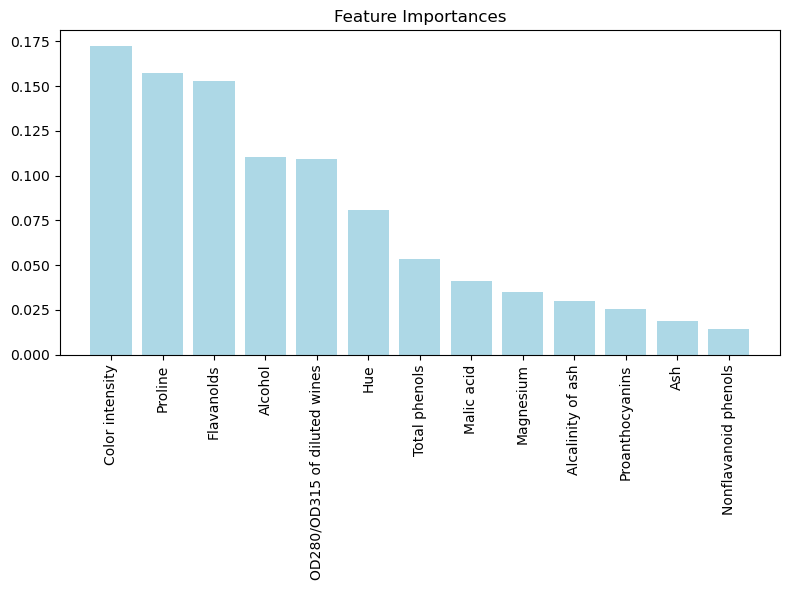

In [28]:
plt.figure(figsize=(8,6))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], color='lightblue', align='center')
plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

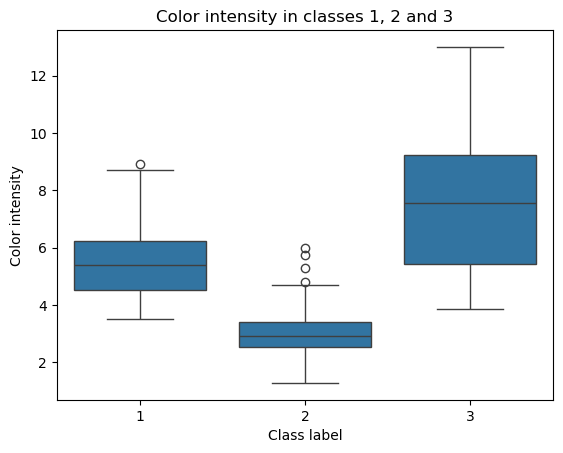

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Class label', y='Color intensity', data=df_wine)
plt.title('Color intensity in classes 1, 2 and 3')
plt.show()

<h4> Exercise3: Consider Gene Expression data. There are four types of the patient condition:

* HC - healthy patients
* STA - stationary patients (medical condition probably isn’t going to improve)
* CR - chronically diseased patients
* RC - recovered patients
    
Propose the top 20 features for differentiating between groups based on Random Forest (with n_estimators=2000 and max_depth=5). Plot boxplots for top3 genes.

In [30]:
annot = pd.read_csv('annotations.csv')
data = pd.read_csv('gene_expression.csv')

# merge data and annotations
data = data.T
data['sample'] = data.index
data = data.merge(annot, 'left').set_index('sample')

# show sample of data
data.head(10)

,RMRP,PHF7,LOC651450,BCAP29,PAPD4,SLC17A3,ATP6V1C2,ZNF768,F3,SLC5A10,...,ATP5J2,LOC400506,LOC649445,CCNE2,TOR2A,SSBP4,LOC286467,MMAA,HDAC8,group
sample,,,,,,,,,,,,,,,,,,,,,
s1,5.243123,3.847586,7.063641,7.832407,3.671807,4.726544,8.269664,3.453405,9.072424,7.482062,...,6.284603,9.441075,7.188731,4.026157,9.200733,6.331886,3.735209,10.008441,7.759521,STA
s2,2.249098,2.453613,7.390492,6.834692,4.634618,4.874429,9.000259,4.177906,9.075465,6.852938,...,5.901787,6.956413,7.349487,6.230069,8.524449,5.969025,4.964406,7.846170,6.170481,STA
s3,5.070240,2.335839,6.317611,7.876383,5.379881,3.699682,9.148588,5.512458,8.911007,5.491385,...,7.035882,9.498795,5.139650,4.795370,8.562788,6.664617,3.525268,10.977964,6.271635,STA
s4,4.886751,5.398647,7.592604,8.421097,4.619076,3.989661,9.412227,4.143202,8.786001,4.952636,...,6.914963,9.467168,4.604784,3.831259,9.125823,6.475059,5.076971,10.674029,6.936457,STA
s5,4.387961,2.330839,7.142551,7.613408,4.283303,3.592627,9.384855,5.178670,8.829352,4.409869,...,7.281618,9.506654,4.896185,3.693916,8.808442,5.955844,3.719662,10.094943,7.843203,STA
s6,2.588099,3.027630,7.460622,7.357772,4.865381,4.103938,9.177133,2.588099,9.237529,5.500045,...,6.170481,8.279189,7.142262,5.828505,9.478665,6.437537,4.222692,8.758300,4.865381,STA
s7,3.777168,3.438830,7.235262,7.280600,5.018710,5.157378,8.550480,4.683500,8.528640,6.712367,...,5.645939,8.431429,7.140878,4.176871,9.623594,5.658326,6.612336,9.681267,7.633009,CR
s8,3.535555,3.614501,7.221107,6.576428,5.634645,4.038663,9.258023,4.864379,8.803467,6.625206,...,4.858685,8.404471,6.579893,4.858685,10.230545,6.849438,5.113671,8.005210,4.768120,CR
s9,4.852919,2.237354,7.194458,6.945499,3.766047,3.002780,9.402554,4.537073,9.180761,5.029154,...,5.693687,8.495965,5.505973,6.265954,10.431064,5.647932,4.722237,8.286052,4.543586,CR
